In [58]:
import pickle
import numpy as np
import pandas as pd
import os
import re

import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable

from nsga_population import *
from typing import List
from individual import Individual, PermutationChromosome

import matplotlib.pyplot as plt
import matplotlib.patches as patches

log_base = "..\\logdata_2\\"
experiment_folders = ["Experiment_2_2025-02-19_23_23_50_random_key_main", "Experiment_2_2025-02-20_22_19_28_hash_base", "Experiment_2_2025-02-24_09_40_06_classical", "Experiment_2_2025-02-24_09_40_06_improved_random_key"] #["Experiment_1_2024-09-27_classical_1", "Experiment_1_2024-09-30_12_05_58_215187", "Experiment_1_2024-09-30_13_51_09_109136", "Experiment_1_2024-09-30_15_31_13_949606"]
subfolder_names = ["pareto_front_abz8_quantum_position_encoding_restricted_0", "pareto_front_abz8_quantum_hash_base_encoding_2", "pareto_front_abz8_classical_8", "pareto_front_abz8_qmea_enhanced_random_key_8"] #"pareto_front_ft20_quantum_hash_base_encoding_0\\pareto_front.pkl"

In [59]:
def import_pareto_front(log_base, experiment_folders, subfolder_name):
    file_path = os.path.join(os.path.join(log_base, experiment_folders), subfolder_name)

    with open(file_path, "rb") as read_pop_dump:
        cur_pop = pickle.load(read_pop_dump)

    X = []
    Y = []
    for individual in cur_pop:
        x, y = individual.cur_fitness
        add_individual = True
        for i in range(len(X)):
            if x == X[i] and y == Y[i]:
                add_individual = False
        if add_individual:
            X.append(x)
            Y.append(y)

    front_array = np.array([X, Y])
    working_index = np.argmin(front_array[0])
    result_list = np.empty_like(front_array)
    front_array = front_array.tolist()

    for i in range(len(X)):
        result_list[0, i] = front_array[0].pop(working_index)
        result_list[1, i] = front_array[1].pop(working_index)
        # Calculate distance to other points to find next index
        min_distance = None
        for j in range(len(front_array[0])):
            cur_distance = np.sqrt(np.sum((result_list[:, i] - np.array([front_array[0][j], front_array[1][j]]))**2))
            if not min_distance or min_distance > cur_distance:
                working_index = j
                min_distance = cur_distance
            
    return result_list

    

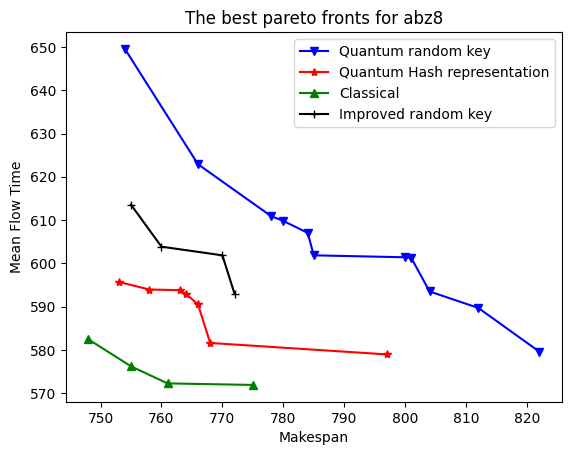

In [60]:
experiment_folders = ["Experiment_2_2025-02-19_23_23_50_random_key_main", "Experiment_2_2025-02-19_23_23_50_random_key_main", "Experiment_2_2025-02-19_23_23_50_random_key_main","Experiment_2_2025-02-19_23_23_50_random_key_main"]
subfolder_names = ["pareto_front_abz9_quantum_position_encoding_restricted_3", "pareto_front_abz9_quantum_position_encoding_restricted_2",  "pareto_front_abz9_quantum_position_encoding_restricted_8", "pareto_front_abz9_quantum_position_encoding_restricted_1"]

style_list = [("v", "b"), ("*", "r"), ("^", "green"), ("+", "black")]
algorithms = ["Quantum random key", "Quantum Hash representation", "Classical", "Improved random key"]
for i, experiment in enumerate(experiment_folders):
    cur_path = os.path.join(subfolder_names[i], "pareto_front.pkl")
    result_list = import_pareto_front(log_base, experiment, cur_path)
    plt.plot(result_list[0, :], result_list[1, :], marker=style_list[i][0], c=style_list[i][1], label=algorithms[i])

plt.title("The best pareto fronts for abz8")
plt.xlabel("Makespan")
plt.ylabel("Mean Flow Time")
plt.legend()
plt.show()

In [61]:
experiment_folders

['Experiment_2_2025-02-19_23_23_50_random_key_main',
 'Experiment_2_2025-02-19_23_23_50_random_key_main',
 'Experiment_2_2025-02-19_23_23_50_random_key_main',
 'Experiment_2_2025-02-19_23_23_50_random_key_main']

In [62]:
result_list

array([[755.  , 760.  , 770.  , 772.  ],
       [613.55, 603.85, 601.85, 592.95]])

In [63]:
start_index = ord("A")
last_index = ord("Z")
alphabet_size = 26

def get_letter_code(index: int, alphabet_size: int, start_index: int) -> str:
    """This funciton is used to create the letter code for the job identifiers

    Parameters
    ----------
    index : int
        The corresponding integer value of the job identifier
    alphabet_size : int
        THe number of different letters in the alphabet
    start_index : int
        The offsett index for the char. For capital letters, this value should be 65 because ord('A') -> 65

    Returns
    -------
    str
        The letter code for the provided job number
    """
    res_list = []
    counter = 0
    while True:
        cur_position = alphabet_size**counter
        rest = index % alphabet_size**(counter+1)
        contribution = rest // cur_position
        if counter > 0:
            contribution -= 1
        res_list.append(contribution)
        if index // alphabet_size**(counter+1) == 0:
            break
        counter += 1

    res_list.reverse()
    letter_indexes = np.array(res_list) + start_index
    res_str = ""
    for letter in letter_indexes:
        res_str += chr(letter)
    
    return res_str

def get_operation_code_list(current_individual) -> list:
    str_operation_list = []
    job_counters = np.ones(shape=current_individual.n_jobs)
    for operation in current_individual.schedule.operation_list:
        # For each operation in the schedule -> find the operation code
        cur_job_number = operation.job
        # Get the number of times the job already has been processed
        cur_count = job_counters[cur_job_number]
        # Increment the job count for later iterations
        job_counters[cur_job_number] += 1
        letter_code = get_letter_code(cur_job_number, alphabet_size, start_index)
        str_operation_list.append(f"{letter_code}{int(cur_count)}")
    
    return str_operation_list

def plot_schedule_as_gnatt(individual, box_height: float=0.4, plot_labels: bool=False, selected_cm: str="plt.cm.cividis", figsize=(10,5), problem_name: str="Unknown"):
    
    fig, ax = plt.subplots(figsize=figsize)

    machine_stop_times = np.zeros(shape=individual.n_machines)
    job_stop_times = np.zeros(shape=individual.n_jobs)
    
    str_operation_list = get_operation_code_list(individual)
    
    for o, cur_operation in enumerate(individual.schedule.operation_list):
        cur_machine = cur_operation.machine
        cur_job_number = cur_operation.job 
        # Create the collor for this job
        cur_color = list(eval(selected_cm)(cur_job_number/(individual.n_jobs-1)))
        cur_color[-1] = 0.6
        cur_color = tuple(cur_color)
        # Get the next start time
        cur_start_time = np.max([machine_stop_times[cur_machine], job_stop_times[cur_job_number]])
        # Create the rectangle for the operation
        rect = patches.Rectangle((cur_start_time, cur_machine - box_height + 1), cur_operation.duration, 2*box_height, linewidth=1, edgecolor="None", facecolor=cur_color, fill=True)
        # Add the operation label in the middle
        if plot_labels:
            ax.annotate(str_operation_list[o], (cur_start_time + cur_operation.duration/2, cur_machine+1), fontsize=10, ha='center', va='center', color="black")
        # update machine and job stop times
        machine_stop_times[cur_machine] = cur_start_time + cur_operation.duration
        job_stop_times[cur_job_number] = cur_start_time + cur_operation.duration
        ax.add_patch(rect)


    ax.set_ylim(0, individual.n_machines + 1)
    ax.set_xlim(0, individual.cur_fitness[0] + 40)
    ax.set_yticks(np.arange(1, individual.n_machines + 1))
    ax.vlines(individual.cur_fitness[0], 1, individual.n_machines, colors="r", lw=2.5)
    ax.text(individual.cur_fitness[0]-40, individual.n_machines + 0.5, f"Makespan: {int(individual.cur_fitness[0])}")
    plt.title(f"Gnatt chart of schedule for the {'unknown'} problem instance")
    plt.xlabel("Time")
    plt.ylabel("Machine ID")
    plt.show()

In [64]:
subfolder_name = "pareto_front_ft20_classical_0" #subfolder_names[0]
experiment_folder = "Experiment_2_2025-02-28_15_18_40_classical" #experiment_folders[0]
file_path = os.path.join(os.path.join(log_base, experiment_folder), os.path.join(subfolder_name, "pareto_front.pkl"))

with open(file_path, "rb") as read_pop_dump:
    cur_pop = pickle.load(read_pop_dump)

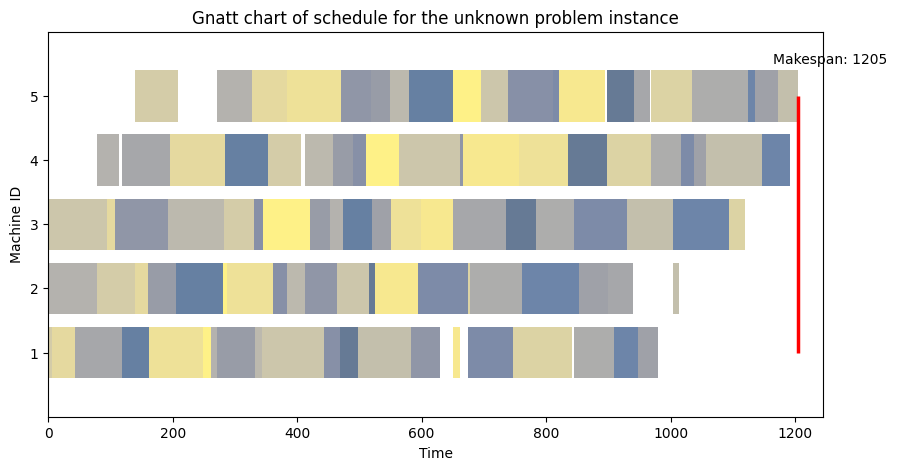

In [65]:
plot_schedule_as_gnatt(cur_pop[6])

In [ ]:
cur_pop[6].schedule.operation_list

array([14, 16, 13,  8,  1, 17, 16, 16,  5, 10, 11, 19, 19, 17,  1, 14, 10,
        6, 14, 10, 14,  4, 19,  6, 11, 13,  4,  4, 13,  1,  0, 17,  0, 11,
        5,  5, 18,  3, 15,  5,  3, 18,  9,  6, 18, 16, 11,  2,  6, 13, 15,
       10,  9,  2,  5, 15, 10, 12, 15,  9, 18,  3,  1,  9,  7,  3,  8,  7,
        4, 17,  7,  8,  0,  6,  3, 11, 17,  0, 19,  0,  2,  2, 16, 12, 12,
        7,  2, 12, 14,  8,  8,  1,  9, 19, 18, 13,  7, 15, 12,  4],
      dtype=int64)

In [69]:
str(get_operation_code_list(cur_pop[6])).replace("[", "").replace("]", "").replace("'", "").replace(" ", "")

'K1,O1,N1,Q1,I1,O2,Q2,K2,F1,B1,Q3,G1,R1,I2,L1,O3,B2,T1,K3,T2,Q4,R2,G2,O4,K4,L2,E1,B3,E2,T3,N2,Q5,L3,O5,F2,G3,L4,N3,E3,R3,K5,G4,A1,F3,B4,E4,A2,S1,G5,H1,T4,M1,L5,D1,R4,B5,F4,N4,S2,S3,F5,P1,T5,I3,J1,N5,D2,S4,E5,A3,C1,D3,R5,P2,J2,J3,H2,S5,A4,D4,I4,C2,A5,P3,I5,H3,J4,M2,M3,P4,D5,H4,C3,J5,P5,C4,M4,H5,C5,M5'

In [45]:
subfolder_name = "pareto_front_ft06_classical_3" #subfolder_names[0]
experiment_folder = "Experiment_2_2025-02-28_15_18_40_classical" #experiment_folders[0]
file_path = os.path.join(os.path.join(log_base, experiment_folder), os.path.join(subfolder_name, "pareto_front.pkl"))

with open(file_path, "rb") as read_pop_dump:
    cur_pop = pickle.load(read_pop_dump)

In [57]:
math.factorial(36)//(math.factorial(6)**6)

2670177736637149247308800

In [51]:
str(get_operation_code_list(cur_pop[4])).replace("[", "").replace("]", "").replace("'", "").replace(" ", "")

'E1,F1,F2,B1,A1,A2,E2,F3,C1,E3,A3,C2,B2,E4,D1,F4,A4,D2,B3,C3,E5,A5,E6,F5,D3,F6,D4,A6,C4,C5,B4,D5,B5,C6,D6,B6'

Calculating the hypervolume

In [430]:
test_points = np.array([[1,3],[2,2],[3,1]])
reference_point = np.array([[5,5]])
n_points = test_points.shape[0]

In [10]:
def calc_hypervolume(front_points: np.ndarray, reference_point: np.ndarray):
    total_volume = 0
    n_points = front_points.shape[0]
    for point in range(n_points):
        if point < n_points-1:
            cur_width = np.abs(front_points[point+1][0] - front_points[point][0])
        else:
            cur_width = np.abs(reference_point[0] - front_points[point][0])

        cur_height = np.abs(reference_point[1] - front_points[point][1])

        total_volume += cur_height * cur_width

    return total_volume

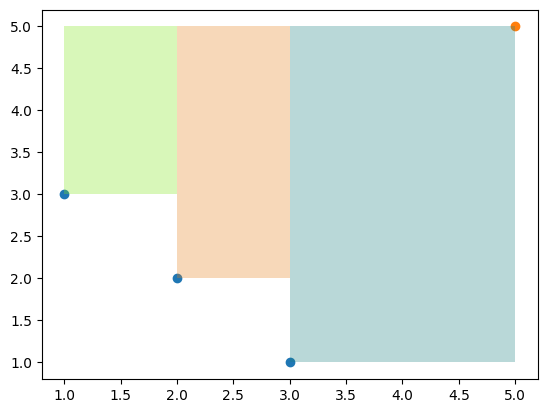

In [450]:
fig, ax = plt.subplots()
plt.scatter(test_points[:, 0], test_points[:, 1])
plt.scatter(reference_point[0][0], reference_point[0][1])

rect_1 = patches.Rectangle((1, 3), 1, 2, linewidth=1, edgecolor="None", facecolor=(0.5, 0.9, 0.1, 0.3), fill=True)
ax.add_patch(rect_1)

rect_1 = patches.Rectangle((2, 2), 1, 3, linewidth=1, edgecolor="None", facecolor=(0.9, 0.5, 0.1, 0.3), fill=True)
ax.add_patch(rect_1)

rect_1 = patches.Rectangle((3, 1), 2, 4, linewidth=1, edgecolor="None", facecolor=(0.1, 0.5, 0.5, 0.3), fill=True)
ax.add_patch(rect_1)

In [23]:
n_repetitions = 10
experiment_folders = [
                        ["Experiment_2_2025-02-28_15_18_40_classical",
                        "Experiment_2_2025-02-19_23_23_50_random_key_main",
                        "Experiment_2_2025-02-20_22_19_28_hash_base",
                        "Experiment_2_2025-02-24_09_40_06_improved_random_key"],
                        ["Experiment_2_2025-02-28_15_18_40_classical_2",
                        "Experiment_2_2025-02-26_08_05_08_random_key_main_2",
                        "Experiment_2_2025-02-26_08_05_08_hash_base_2",
                        "Experiment_2_2025-02-25_10_04_37_improved_random_key_2"]
                    ]

method_names = [["classical", "quantum_position_encoding_restricted", "quantum_hash_base_encoding", "qmea_enhanced_random_key"], ["classical", "quantum_position_encoding_restricted", "quantum_hash_base_encoding", "qmea_enhanced_random_key"]]
problem_names = [["ft06", "ft10", "ft20", "abz7", "abz8", "abz9", "la28", "la40"], ["la21", "la22", "la23", "la24", "la25", "la26", "la27", "la29"]]
front_dataset = {"Problem" : [], "Method" : [], "Repetition" : [], "Makespan" : [], "Mean Flow Time" : []}
for block in range(len(problem_names)):
    for problem_name in problem_names[block]:
        for i, method_name in enumerate(method_names[block]):
            for repetition in range(n_repetitions):
                # Create the path to the front file
                file_path = os.path.join(os.path.join(log_base, experiment_folders[block][i]), os.path.join(f"pareto_front_{problem_name}_{method_name}_{repetition}", "pareto_front.pkl"))
                # Import the population object
                with open(file_path, "rb") as read_pop_dump:
                    cur_front = pickle.load(read_pop_dump)

                for indiv in cur_front:
                    front_dataset["Problem"].append(problem_name)
                    front_dataset["Method"].append(method_name)
                    front_dataset["Repetition"].append(repetition)
                    front_dataset["Makespan"].append(indiv.cur_fitness[0])
                    front_dataset["Mean Flow Time"].append(indiv.cur_fitness[1])

            
front_dataset = pd.DataFrame(front_dataset)
front_dataset.drop_duplicates(inplace=True)
min_columns = front_dataset.groupby(["Problem"])[["Makespan", "Mean Flow Time"]].transform(lambda x: x.min()).rename(columns={"Makespan" : "min makespan", "Mean Flow Time" : "min mean flow time"})
max_columns = front_dataset.groupby(["Problem"])[["Makespan", "Mean Flow Time"]].transform(lambda x: x.max()).rename(columns={"Makespan" : "max makespan", "Mean Flow Time" : "max mean flow time"})
front_dataset = pd.concat([front_dataset, min_columns, max_columns], axis=1)
front_dataset

,Problem,Method,Repetition,Makespan,Mean Flow Time,min makespan,min mean flow time,max makespan,max mean flow time
0,ft06,classical,0,58.0,39.666667,57.0,39.666667,58.0,42.50
1,ft06,classical,0,57.0,42.500000,57.0,39.666667,58.0,42.50
83,ft06,classical,1,58.0,39.666667,57.0,39.666667,58.0,42.50
84,ft06,classical,1,57.0,42.500000,57.0,39.666667,58.0,42.50
170,ft06,classical,2,58.0,39.666667,57.0,39.666667,58.0,42.50
...,...,...,...,...,...,...,...,...,...
14444,la29,qmea_enhanced_random_key,9,1238.0,995.800000,1210.0,920.550000,1611.0,1080.75
14445,la29,qmea_enhanced_random_key,9,1300.0,955.400000,1210.0,920.550000,1611.0,1080.75
14446,la29,qmea_enhanced_random_key,9,1265.0,960.250000,1210.0,920.550000,1611.0,1080.75
14447,la29,qmea_enhanced_random_key,9,1255.0,984.650000,1210.0,920.550000,1611.0,1080.75


Normalization of makespan and mean flow time with min/max scaling

In [24]:
def min_max_scaling(x):
    cur_makespan = (x["Makespan"] - x["min makespan"])/(x["max makespan"] - x["min makespan"])
    cur_mean_flow_time = (x["Mean Flow Time"] - x["min mean flow time"])/(x["max mean flow time"] - x["min mean flow time"])
    new_columns = pd.concat([x, cur_makespan, cur_mean_flow_time], axis=1).reset_index(drop=True)
    return new_columns

norm_df = front_dataset.groupby(["Problem"]).apply(min_max_scaling, include_groups=False).reset_index().rename(columns={0 : "Makespan norm", 1 : "Mean Flow Time norm"})
norm_df

,Problem,level_1,Method,Repetition,Makespan,Mean Flow Time,min makespan,min mean flow time,max makespan,max mean flow time,Makespan norm,Mean Flow Time norm
0,abz7,0,classical,0,751.0,593.000000,694.0,574.500000,805.0,640.45,0.513514,0.280516
1,abz7,1,classical,0,702.0,614.100000,694.0,574.500000,805.0,640.45,0.072072,0.600455
2,abz7,2,classical,0,735.0,593.100000,694.0,574.500000,805.0,640.45,0.369369,0.282032
3,abz7,3,classical,0,712.0,605.550000,694.0,574.500000,805.0,640.45,0.162162,0.470811
4,abz7,4,classical,0,721.0,600.600000,694.0,574.500000,805.0,640.45,0.243243,0.395754
...,...,...,...,...,...,...,...,...,...,...,...,...
3781,la40,181,qmea_enhanced_random_key,9,1291.0,1100.533333,1275.0,1044.066667,1528.0,1181.80,0.063241,0.409971
3782,la40,182,qmea_enhanced_random_key,9,1354.0,1091.333333,1275.0,1044.066667,1528.0,1181.80,0.312253,0.343175
3783,la40,183,qmea_enhanced_random_key,9,1332.0,1099.466667,1275.0,1044.066667,1528.0,1181.80,0.225296,0.402227
3784,la40,184,qmea_enhanced_random_key,9,1341.0,1095.066667,1275.0,1044.066667,1528.0,1181.80,0.260870,0.370281


Find the Nadir point for both the normalized solutions and the raw points. Note that it is defined as the maximum in both dimensions 

In [25]:
w_reference_point = front_dataset.groupby(["Problem"])[["Makespan", "Mean Flow Time"]].transform(lambda x: x.max()).rename(columns={"Makespan" : "Reference_1", "Mean Flow Time" : "Reference_2"})
w_reference_point_norm = norm_df.groupby(["Problem"])[["Makespan norm", "Mean Flow Time norm"]].transform(lambda x: x.max()).rename(columns={"Makespan norm" : "Reference_1", "Mean Flow Time norm" : "Reference_2"})

Add the reference points to the dataset

In [26]:
hypervol_ready = pd.concat([front_dataset, w_reference_point], axis=1)
hypervol_ready_norm = pd.concat([norm_df, w_reference_point_norm], axis=1)

Calculate the Hypervolume and find the agregate over the repetitions

In [27]:
hypervol_ready

,Problem,Method,Repetition,Makespan,Mean Flow Time,min makespan,min mean flow time,max makespan,max mean flow time,Reference_1,Reference_2
0,ft06,classical,0,58.0,39.666667,57.0,39.666667,58.0,42.50,58.0,42.50
1,ft06,classical,0,57.0,42.500000,57.0,39.666667,58.0,42.50,58.0,42.50
83,ft06,classical,1,58.0,39.666667,57.0,39.666667,58.0,42.50,58.0,42.50
84,ft06,classical,1,57.0,42.500000,57.0,39.666667,58.0,42.50,58.0,42.50
170,ft06,classical,2,58.0,39.666667,57.0,39.666667,58.0,42.50,58.0,42.50
...,...,...,...,...,...,...,...,...,...,...,...
14444,la29,qmea_enhanced_random_key,9,1238.0,995.800000,1210.0,920.550000,1611.0,1080.75,1611.0,1080.75
14445,la29,qmea_enhanced_random_key,9,1300.0,955.400000,1210.0,920.550000,1611.0,1080.75,1611.0,1080.75
14446,la29,qmea_enhanced_random_key,9,1265.0,960.250000,1210.0,920.550000,1611.0,1080.75,1611.0,1080.75
14447,la29,qmea_enhanced_random_key,9,1255.0,984.650000,1210.0,920.550000,1611.0,1080.75,1611.0,1080.75


In [28]:
hypervolume_res = hypervol_ready.groupby(["Problem", "Method", "Repetition"]).apply(lambda x: calc_hypervolume(x[["Makespan", "Mean Flow Time"]].to_numpy(), x[["Reference_1", "Reference_2"]].to_numpy()[0,:]), include_groups=False) 
hypervolume_res = hypervolume_res.groupby(["Problem", "Method"]).agg(["mean", "min", "max", "std"]).reset_index()
hypervolume_res_norm = hypervol_ready_norm.groupby(["Problem", "Method", "Repetition"]).apply(lambda x: calc_hypervolume(x[["Makespan norm", "Mean Flow Time norm"]].to_numpy(), x[["Reference_1", "Reference_2"]].to_numpy()[0,:]), include_groups=False) 
hypervolume_res_norm = hypervolume_res_norm.groupby(["Problem", "Method"]).agg(["mean", "min", "max", "std"]).reset_index()

In [29]:
hypervolume_res

,Problem,Method,mean,min,max,std
0,abz7,classical,6645.085000,2921.800000,9697.250000,2127.345012
1,abz7,qmea_enhanced_random_key,5684.925000,3308.700000,9511.200000,1845.439601
2,abz7,quantum_hash_base_encoding,5207.445000,2079.500000,10656.900000,2566.954971
3,abz7,quantum_position_encoding_restricted,6639.080000,5196.000000,9981.900000,1316.602903
4,abz8,classical,9073.895000,5875.700000,14566.200000,2894.415191
...,...,...,...,...,...,...
59,la29,quantum_position_encoding_restricted,62442.820000,42911.500000,74165.800000,9396.797230
60,la40,classical,30462.380000,21153.866667,47870.200000,9713.992652
61,la40,qmea_enhanced_random_key,33291.133333,15737.666667,54157.333333,11933.323475
62,la40,quantum_hash_base_encoding,27699.060000,15064.800000,49742.133333,11164.235039


<Axes: title={'center': 'Mean Hypervolume for different benchmarks'}, xlabel='Problem', ylabel='max'>

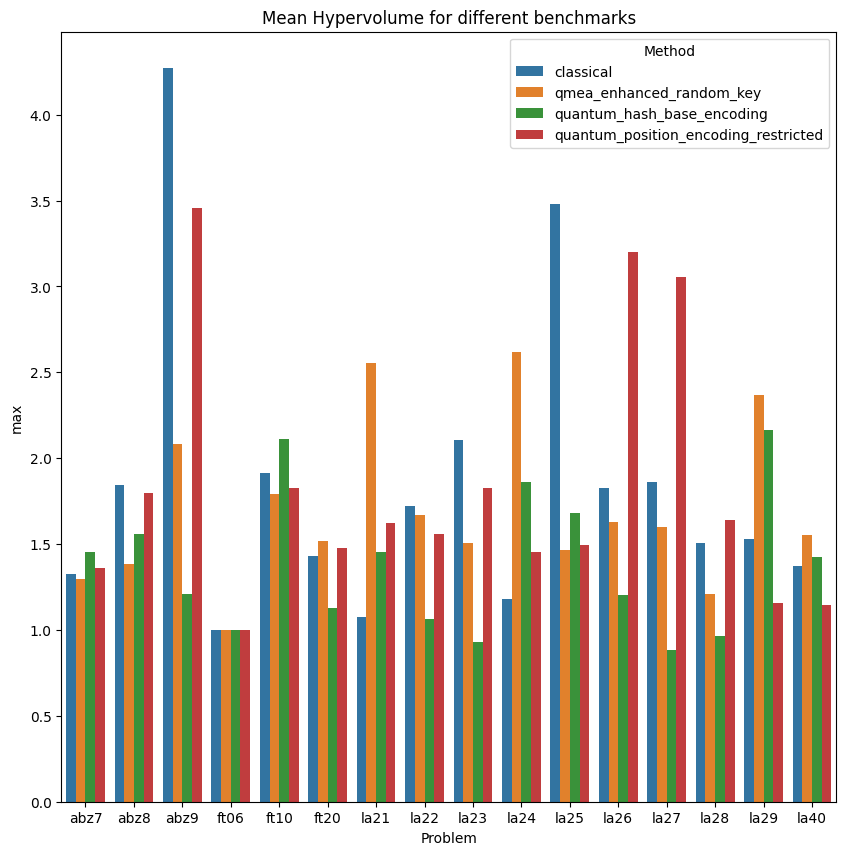

In [38]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("Mean Hypervolume for different benchmarks")
sns.barplot(data=hypervolume_res_norm, x="Problem", y="max", hue="Method", ax=ax)

In [544]:
test = np.arange(10)

In [547]:
(test - test.min())/(test.max() - test.min())

array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])